# Understanding the Autocorrelation Plot (ACF)

An autocorrelation plot (ACF — AutoCorrelation Function) shows the **correlation of a time series with itself at every lag k** (1, 2, 3, …). Each bar represents how strongly y(t) is correlated with y(t+k). Horizontal dashed bands mark the significance threshold — bars outside the band indicate that lag is statistically significant. It answers: *At which lags does the past predict the future?*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

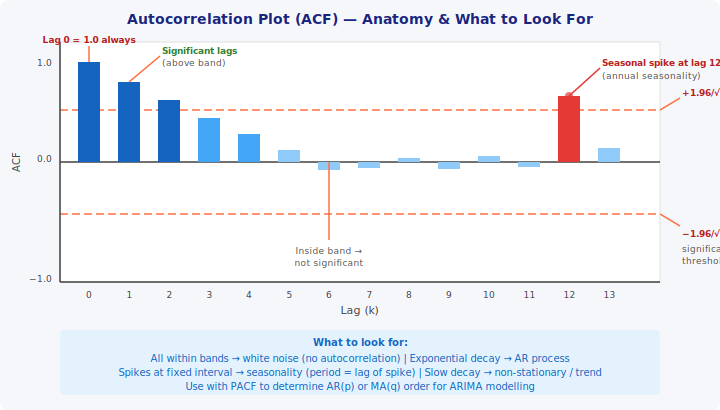

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="410"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="720" height="410" fill="#F5F7FA" rx="8"/>
  <text x="360" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Autocorrelation Plot (ACF) — Anatomy &amp; What to Look For</text>

  <!-- plot area -->
  <rect x="60" y="42" width="600" height="240" fill="white" stroke="#E0E0E0"/>

  <!-- Zero line -->
  <line x1="60" y1="162" x2="660" y2="162" stroke="#424242" stroke-width="1.5"/>

  <!-- Confidence bands (±1.96/√n) -->
  <line x1="60" y1="110" x2="660" y2="110" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="8,4"/>
  <line x1="60" y1="214" x2="660" y2="214" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="8,4"/>

  <!-- Lag-0 bar (always 1.0) -->
  <rect x="78"  y="62"  width="22" height="100" fill="#1565C0"/>
  <!-- Lag-1 bar (high positive) -->
  <rect x="118" y="82"  width="22" height="80"  fill="#1565C0"/>
  <!-- Lag-2 bar (still significant) -->
  <rect x="158" y="100" width="22" height="62"  fill="#1565C0"/>
  <!-- Lag-3 bar (moderate) -->
  <rect x="198" y="118" width="22" height="44"  fill="#42A5F5"/>
  <!-- Lag-4 bar (near boundary) -->
  <rect x="238" y="134" width="22" height="28"  fill="#42A5F5"/>
  <!-- Lag-5 bar (inside band) -->
  <rect x="278" y="150" width="22" height="12"  fill="#90CAF9"/>
  <!-- Lag-6 bar (slightly negative, inside) -->
  <rect x="318" y="162" width="22" height="8"   fill="#90CAF9"/>
  <!-- Lag-7 bar (inside band) -->
  <rect x="358" y="162" width="22" height="6"   fill="#90CAF9"/>
  <!-- Lag-8 (inside) -->
  <rect x="398" y="158" width="22" height="4"   fill="#90CAF9"/>
  <!-- Lag-9 (inside) -->
  <rect x="438" y="162" width="22" height="7"   fill="#90CAF9"/>
  <!-- Lag-10 (inside) -->
  <rect x="478" y="156" width="22" height="6"   fill="#90CAF9"/>
  <!-- Lag-11 (inside) -->
  <rect x="518" y="162" width="22" height="5"   fill="#90CAF9"/>
  <!-- Lag-12 (seasonal spike! above band) -->
  <rect x="558" y="96"  width="22" height="66"  fill="#E53935"/>
  <!-- Lag-13 (back inside) -->
  <rect x="598" y="148" width="22" height="14"  fill="#90CAF9"/>

  <!-- X-axis (lag ticks) -->
  <line x1="60" y1="282" x2="660" y2="282" stroke="#424242" stroke-width="1.5"/>
  <line x1="60" y1="42"  x2="60"  y2="282" stroke="#424242" stroke-width="1.5"/>

  <!-- Lag labels -->
  <text x="89"  y="298" text-anchor="middle" font-size="9" fill="#424242">0</text>
  <text x="129" y="298" text-anchor="middle" font-size="9" fill="#424242">1</text>
  <text x="169" y="298" text-anchor="middle" font-size="9" fill="#424242">2</text>
  <text x="209" y="298" text-anchor="middle" font-size="9" fill="#424242">3</text>
  <text x="249" y="298" text-anchor="middle" font-size="9" fill="#424242">4</text>
  <text x="289" y="298" text-anchor="middle" font-size="9" fill="#424242">5</text>
  <text x="329" y="298" text-anchor="middle" font-size="9" fill="#424242">6</text>
  <text x="369" y="298" text-anchor="middle" font-size="9" fill="#424242">7</text>
  <text x="409" y="298" text-anchor="middle" font-size="9" fill="#424242">8</text>
  <text x="449" y="298" text-anchor="middle" font-size="9" fill="#424242">9</text>
  <text x="489" y="298" text-anchor="middle" font-size="9" fill="#424242">10</text>
  <text x="529" y="298" text-anchor="middle" font-size="9" fill="#424242">11</text>
  <text x="569" y="298" text-anchor="middle" font-size="9" fill="#424242">12</text>
  <text x="609" y="298" text-anchor="middle" font-size="9" fill="#424242">13</text>
  <text x="360" y="314" text-anchor="middle" font-size="11" fill="#424242">Lag (k)</text>

  <!-- Y-axis labels -->
  <text x="52" y="66"  text-anchor="end" font-size="9" fill="#424242">1.0</text>
  <text x="52" y="162" text-anchor="end" font-size="9" fill="#424242">0.0</text>
  <text x="52" y="282" text-anchor="end" font-size="9" fill="#424242">−1.0</text>
  <text x="20" y="162" text-anchor="middle" font-size="10" fill="#424242"
        transform="rotate(-90 20 162)">ACF</text>

  <!-- ANNOTATIONS -->
  <!-- Lag-0 annotation -->
  <line x1="89"  y1="62" x2="89"  y2="46" stroke="#FF7043" stroke-width="1.5"/>
  <text x="89"  y="43" text-anchor="middle" font-size="9" font-weight="bold" fill="#B71C1C">Lag 0 = 1.0 always</text>

  <!-- Confidence band label -->
  <line x1="660" y1="110" x2="680" y2="98" stroke="#FF7043" stroke-width="1.5"/>
  <text x="682" y="96"  font-size="9" font-weight="bold" fill="#B71C1C">+1.96/√n</text>
  <line x1="660" y1="214" x2="680" y2="226" stroke="#FF7043" stroke-width="1.5"/>
  <text x="682" y="237" font-size="9" font-weight="bold" fill="#B71C1C">−1.96/√n</text>
  <text x="682" y="252" font-size="9" fill="#555">significance</text>
  <text x="682" y="264" font-size="9" fill="#555">threshold</text>

  <!-- Significant lag annotation -->
  <line x1="129" y1="82" x2="160" y2="56" stroke="#FF7043" stroke-width="1.5"/>
  <text x="162" y="54" font-size="9" fill="#2E7D32" font-weight="bold">Significant lags</text>
  <text x="162" y="66" font-size="9" fill="#555">(above band)</text>

  <!-- Inside band annotation -->
  <line x1="329" y1="162" x2="329" y2="240" stroke="#FF7043" stroke-width="1.5"/>
  <text x="329" y="254" text-anchor="middle" font-size="9" fill="#555">Inside band →</text>
  <text x="329" y="266" text-anchor="middle" font-size="9" fill="#555">not significant</text>

  <!-- Seasonal spike annotation -->
  <line x1="569" y1="96" x2="600" y2="68" stroke="#E53935" stroke-width="1.5"/>
  <circle cx="569" cy="96" r="4" fill="#E53935" opacity="0.7"/>
  <text x="602" y="66" font-size="9" font-weight="bold" fill="#B71C1C">Seasonal spike at lag 12</text>
  <text x="602" y="79" font-size="9" fill="#555">(annual seasonality)</text>

  <!-- Takeaway -->
  <rect x="60" y="330" width="600" height="65" fill="#E3F2FD" rx="4"/>
  <text x="360" y="346" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="360" y="362" text-anchor="middle" font-size="10" fill="#1565C0">All within bands → white noise (no autocorrelation)   |   Exponential decay → AR process</text>
  <text x="360" y="376" text-anchor="middle" font-size="10" fill="#1565C0">Spikes at fixed interval → seasonality (period = lag of spike)   |   Slow decay → non-stationary / trend</text>
  <text x="360" y="390" text-anchor="middle" font-size="10" fill="#1565C0">Use with PACF to determine AR(p) or MA(q) order for ARIMA modelling</text>
</svg>
"""
display(SVG(_svg))

## Interpreting an ACF Plot

| Pattern | What it means | Model hint |
|---|---|---|
| **All bars within bands** | White noise — no structure | No time-series model needed |
| **Exponential decay to zero** | AR(p) process | AR order = lag where it cuts off |
| **One significant spike then zero** | MA(1) process | MA order = 1 |
| **Slow linear decay** | Non-stationary data (trend) | Difference the series first |
| **Spikes at regular lag k** | Seasonal pattern with period k | Add seasonal differencing |
| **Cut-off after lag q** | MA(q) process | MA order = q |

**ACF vs PACF:**
- **ACF** — total correlation at lag k (includes indirect effects through intermediate lags)
- **PACF** — partial correlation at lag k (controls for shorter lags)
- Use both together: ACF decays + PACF cuts off → AR model; ACF cuts off + PACF decays → MA model

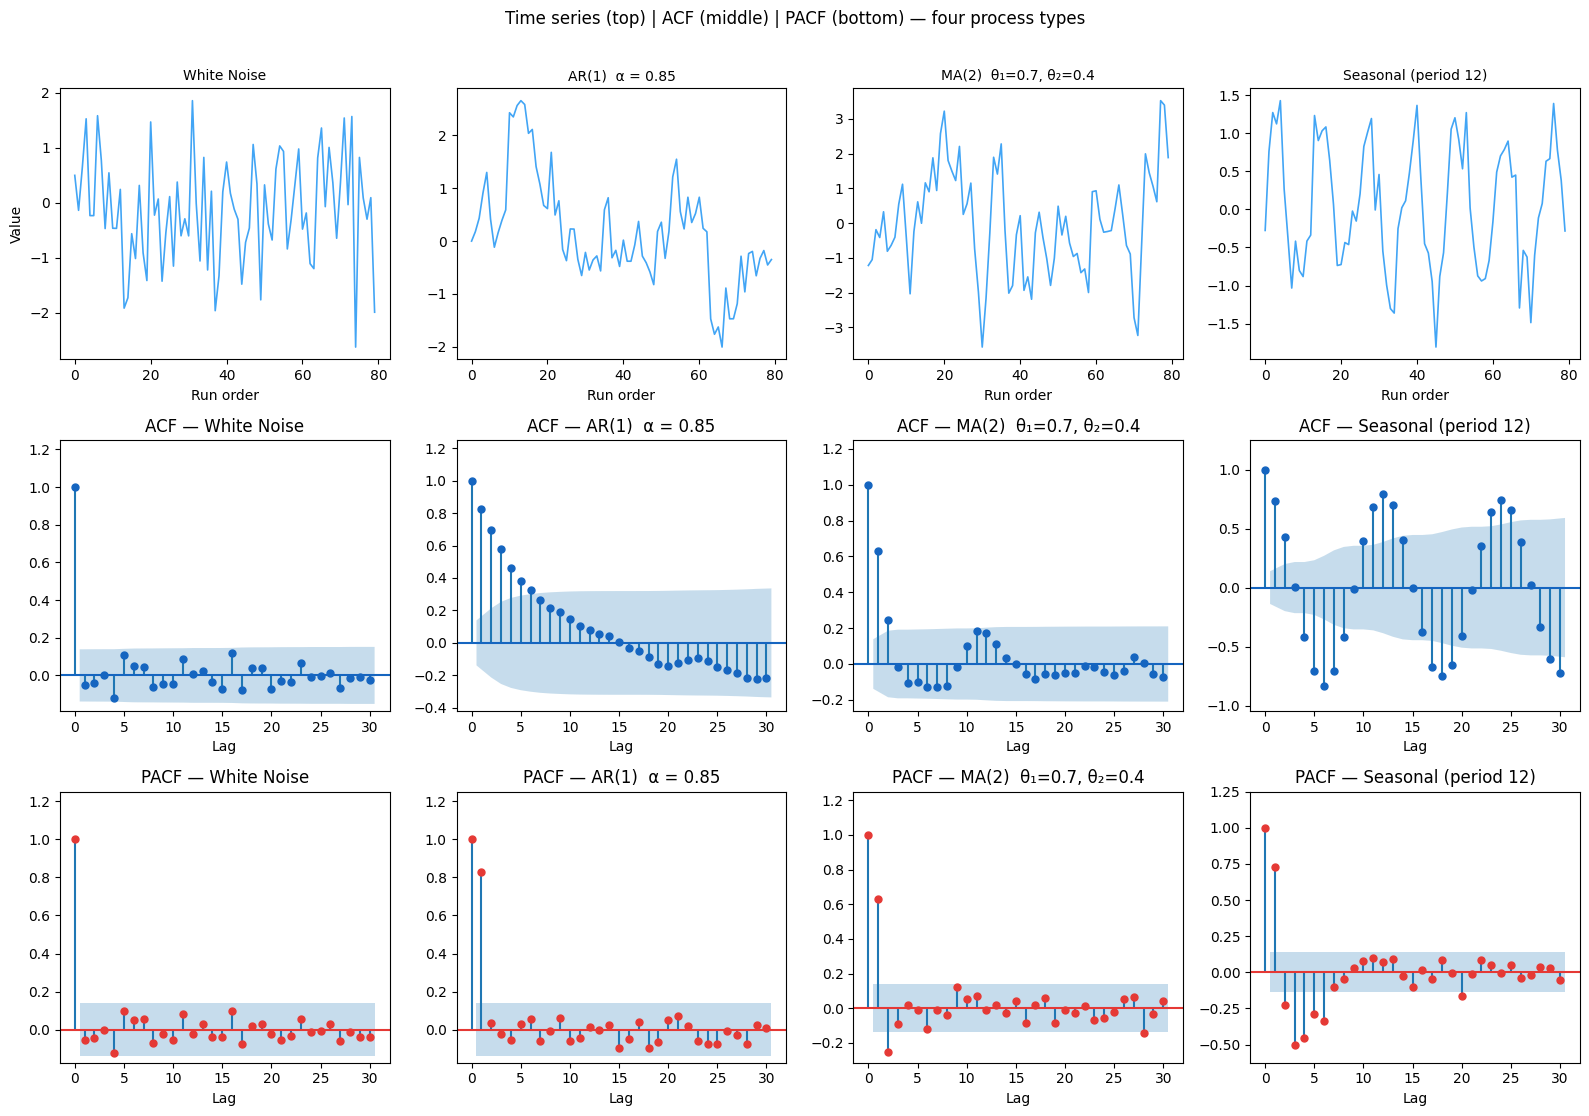

In [3]:
np.random.seed(42)
n = 200

# White noise
white_noise = np.random.normal(0, 1, n)

# AR(1) with high alpha
ar1 = np.zeros(n)
for i in range(1, n):
    ar1[i] = 0.85 * ar1[i-1] + np.random.normal(0, 0.5)

# MA(2)
eps = np.random.normal(0, 1, n + 2)
ma2 = eps[2:] + 0.7 * eps[1:-1] + 0.4 * eps[:-2]

# Seasonal (period=12)
seasonal = np.sin(2 * np.pi * np.arange(n) / 12) + np.random.normal(0, 0.3, n)

fig, axes = plt.subplots(3, 4, figsize=(16, 11))

series_list = [
    (white_noise, 'White Noise'),
    (ar1,         'AR(1)  α = 0.85'),
    (ma2,         'MA(2)  θ₁=0.7, θ₂=0.4'),
    (seasonal,    'Seasonal (period 12)'),
]

for col, (data, title) in enumerate(series_list):
    # Time series
    axes[0, col].plot(data[:80], linewidth=1.2, color='#42A5F5')
    axes[0, col].set_title(title, fontsize=10)
    axes[0, col].set_xlabel('Run order')
    if col == 0:
        axes[0, col].set_ylabel('Value')

    # ACF
    plot_acf(data, lags=30, ax=axes[1, col], color='#1565C0',
             title=f'ACF — {title}', auto_ylims=True)
    axes[1, col].set_xlabel('Lag')

    # PACF
    plot_pacf(data, lags=30, ax=axes[2, col], color='#E53935',
              method='ywm', title=f'PACF — {title}', auto_ylims=True)
    axes[2, col].set_xlabel('Lag')

plt.suptitle('Time series (top) | ACF (middle) | PACF (bottom) — four process types', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Diagnosing autocorrelation structure in time series data |
| **X-axis** | Lag k — how many steps back |
| **Y-axis** | Correlation coefficient (−1 to +1) |
| **Confidence bands** | ±1.96/√n — bars outside = statistically significant |
| **Lag 0** | Always 1.0 — a series is perfectly correlated with itself |
| **Seasonal spike** | Spike at lag k → period = k (e.g., lag 12 = annual for monthly data) |
| **Slow decay** | Series has a trend — needs differencing before modeling |
| **Pairs with** | Lag plot (visual) + PACF (AR vs MA diagnosis) + run sequence plot |